In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\Administrator\Downloads\offline_training_centers.csv")
df

,company,course,review,rating,cost (INR),duration (weeks),mode,placement assistance(past 3),enrollemnt count (past 3),scholarships,mobile application,certification,languages offered
0,Basant Technologies,Java Backend,Highly recommended for freshers,4.6,115366,13,Hybrid,No,638,No,Yes,Yes,"English, Kannada"
1,Intellipaat Bangalore Center,Cyber Security,Affordable and beginner friendly,4.4,32988,13,Offline,Yes,504,No,No,Yes,English
2,NIIT,Java Backend,Interactive sessions and assignments,4.8,86685,20,Offline,75%,3579,Yes,Yes,Yes,"English, Tamil"
3,NIIT,Cloud Computing,Highly recommended for freshers,3.9,137080,10,Hybrid,90%,3532,Yes,Yes,Yes,"English, Kannada"
4,NIIT,Cyber Security,Very practical and industry oriented course,4.6,146297,28,Offline,Yes,3921,No,Yes,Yes,"English, Kannada"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,NIIT,Data Science,Strong placement support,4.3,65036,11,Offline,Yes,1030,No,No,Yes,English
1196,Imarticus Learning,Cloud Computing,Good mentorship and hands-on projects,3.9,29499,39,Hybrid,No,2706,No,No,Yes,English
1197,NIIT,Machine Learning,Affordable and beginner friendly,4.5,147132,26,Offline,90%,1870,Yes,No,Yes,"English, Kannada"
1198,NIIT,Data Science,Very practical and industry oriented course,4.1,146817,9,Offline,85%,2616,No,No,Yes,"English, Tamil"


In [3]:
df.describe()


,rating,cost (INR),duration (weeks),enrollemnt count (past 3)
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,4.340167,84756.308333,23.882500,2082.570000
std,0.319356,37686.842770,9.404027,1132.221874
min,3.800000,20024.000000,8.000000,151.000000
25%,4.100000,52089.500000,16.000000,1076.500000
50%,4.300000,85530.500000,24.000000,2063.500000
75%,4.600000,116962.250000,32.000000,3116.500000
max,4.900000,149955.000000,40.000000,4000.000000


In [4]:
df.columns


Index(['company', 'course', 'review', 'rating', 'cost (INR)',
       'duration (weeks)', 'mode', 'placement assistance(past 3)',
       'enrollemnt count (past 3)', 'scholarships', 'mobile application',
       'certification', 'languages offered'],
      dtype='object')

In [5]:
df.isnull().sum()

company                         0
course                          0
review                          0
rating                          0
cost (INR)                      0
duration (weeks)                0
mode                            0
placement assistance(past 3)    0
enrollemnt count (past 3)       0
scholarships                    0
mobile application              0
certification                   0
languages offered               0
dtype: int64

In [6]:
df.duplicated().sum()

0

In [7]:
df.columns = [
'company',
'course',
'review',
'rating',
'cost',
'duration',
'mode',
'placement_assistance',
'enrollment',
'scholarships',
'mobile_app',
'certification',
'languages'
]

In [8]:
#Handle Missing Values
df = df.fillna({
    'review':0,
    'rating':df['rating'].mean(),
    'placement_assistance':0,
    'scholarships':0,
    'mobile_app':0,
    'certification':0
})

In [9]:
# Convert Datatypes
df['rating'] = df['rating'].astype(float)
df['cost'] = df['cost'].astype(float)
df['duration'] = df['duration'].astype(int)
df['enrollment'] = df['enrollment'].astype(int)

In [10]:
#convert the object datatype 

df['scholarships'] = df['scholarships'].map({'Yes':1,'No':0})
df['mobile_app'] = df['mobile_app'].map({'Yes':1,'No':0})
df['certification'] = df['certification'].map({'Yes':1,'No':0})

In [11]:
# Fix the placement assistance column

df['placement_assistance'] = df['placement_assistance'].astype(str)

df['placement_assistance'] = df['placement_assistance'].str.replace('%','')

df['placement_assistance'] = df['placement_assistance'].replace({
    'Yes':100,
    'No':0
})

df['placement_assistance'] = pd.to_numeric(df['placement_assistance'], errors='coerce')

In [12]:
#FIx Review Column

df['review'] = pd.to_numeric(df['review'], errors='coerce')


# Fix the missing values 

df = df.fillna(df.mean(numeric_only=True))

In [14]:
df

,company,course,review,rating,cost,duration,mode,placement_assistance,enrollment,scholarships,mobile_app,certification,languages
0,Basant Technologies,Java Backend,NaN,4.6,115366.0,13,Hybrid,0,638,0,1,1,"English, Kannada"
1,Intellipaat Bangalore Center,Cyber Security,NaN,4.4,32988.0,13,Offline,100,504,0,0,1,English
2,NIIT,Java Backend,NaN,4.8,86685.0,20,Offline,75,3579,1,1,1,"English, Tamil"
3,NIIT,Cloud Computing,NaN,3.9,137080.0,10,Hybrid,90,3532,1,1,1,"English, Kannada"
4,NIIT,Cyber Security,NaN,4.6,146297.0,28,Offline,100,3921,0,1,1,"English, Kannada"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,NIIT,Data Science,NaN,4.3,65036.0,11,Offline,100,1030,0,0,1,English
1196,Imarticus Learning,Cloud Computing,NaN,3.9,29499.0,39,Hybrid,0,2706,0,0,1,English
1197,NIIT,Machine Learning,NaN,4.5,147132.0,26,Offline,90,1870,1,0,1,"English, Kannada"
1198,NIIT,Data Science,NaN,4.1,146817.0,9,Offline,85,2616,0,0,1,"English, Tamil"


In [ ]:
1. Course Comparison Across EdTech Companies
Goal
Help students compare similar courses offered by different training institutes.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def course_comparison(df, course_name="Data Science"):


    filtered = (
        df[df["course"] == course_name]
        .groupby("company")
        .agg(
            rating=("rating", "mean"),
            cost=("cost", "mean"),
            placement=("placement_assistance", "mean")
        )
        .reset_index()
    )

    filtered["score"] = (
        0.4 * (filtered["rating"] / 5) +
        0.35 * (1 - filtered["cost"] / filtered["cost"].max()) +
        0.25 * (filtered["placement"] / 100)
    )

 
    top10 = (
        filtered.sort_values("score", ascending=False)
        .head(10)
        .reset_index(drop=True)
    )

    top10["rank"] = top10.index + 1


    print(f"\nTop Institutes for {course_name}\n")
    print(top10[["rank", "company", "rating", "cost", "placement"]].to_string(index=False))

    print(f"\nBest Institute → {top10.iloc[0]['company']}")

    colors = ["green" if i == 0 else "royalblue" for i in range(len(top10))]

    x = np.arange(len(top10))

 
    fig, axes = plt.subplots(3, 1, figsize=(11, 11))

    fig.suptitle(f"Top Institutes for {course_name}", fontsize=14, fontweight="bold")

    axes[0].bar(x, top10["rating"], color=colors)
    axes[0].set_title("Average Rating")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(top10["company"], rotation=30, ha="right")
    axes[0].set_ylim(0, 5.5)

    axes[1].bar(x, top10["cost"], color=colors)
    axes[1].set_title("Average Course Cost (₹)")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(top10["company"], rotation=30, ha="right")

   
    axes[2].bar(x, top10["placement"], color=colors)
    axes[2].set_title("Placement Assistance (%)")
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(top10["company"], rotation=30, ha="right")
    axes[2].set_ylim(0, 100)

    plt.tight_layout()
    plt.show()


Top Institutes for Data Science

 rank                      company   rating          cost  placement
    1                    DataMites 4.368421  74376.736842  86.315789
    2                 AnalytixLabs 4.185714  71519.761905  68.809524
    3 Intellipaat Bangalore Center 4.461905  79092.380952  60.714286
    4           Imarticus Learning 4.266667  90571.111111  78.888889
    5     Great Learning Institute 4.283333  77741.166667  61.111111
    6                         NIIT 4.290000 104397.300000  89.250000
    7          Basant Technologies 4.293333  89337.400000  68.333333
    8          Besant Technologies 4.282609  84782.391304  61.521739

Best Institute → DataMites


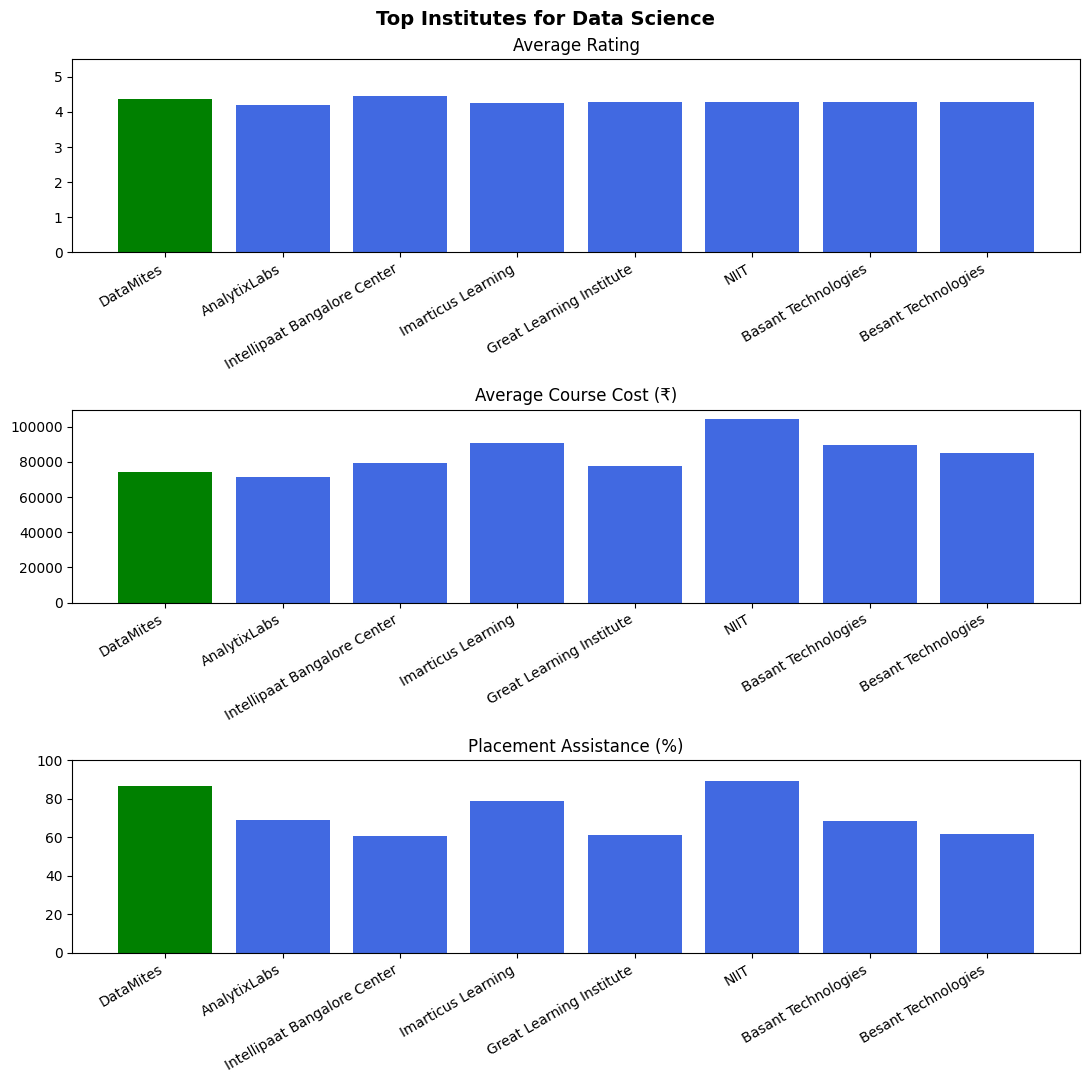

In [31]:
course_comparison(df, "Data Science")

In [ ]:
2. ROI Analysis (Cost vs Placement vs Rating)
Goal
Evaluate the return on investment (ROI) for each course.


===== Course ROI Ranking =====
 rank                 course  roi_score
    1         Cyber Security  65.456074
    2           Java Backend  65.103436
    3        Cloud Computing  64.967110
    4           Data Science  64.240724
    5 Full Stack Development  64.127226
    6         Python Backend  63.855482
    7         AI Engineering  63.837124
    8       Machine Learning  62.284320


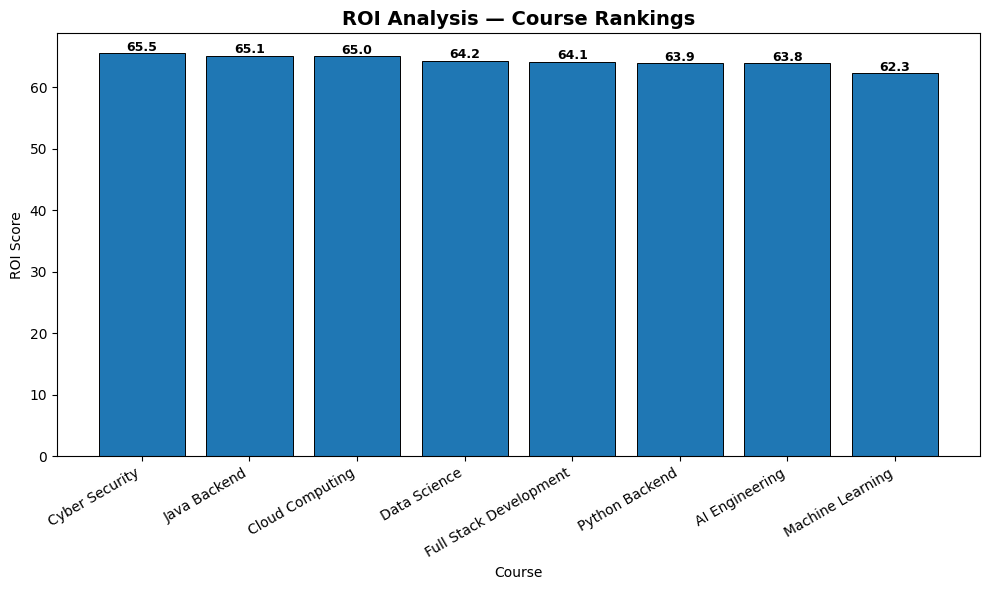

In [36]:
df["rating_norm"] = df["rating"] / df["rating"].max()
df["placement_norm"] = df["placement_assistance"] / 100
df["enroll_norm"] = df["enrollment"] / df["enrollment"].max()
df["cost_norm"] = df["cost"] / df["cost"].max()

df["roi_score"] = (
    0.5 * df["rating_norm"] +
    0.3 * df["placement_norm"] +
    0.2 * df["enroll_norm"] -
    0.2 * df["cost_norm"]
) * 100


course_df = (
    df.groupby("course")["roi_score"]
    .mean()
    .reset_index()
    .sort_values("roi_score", ascending=False)
    .reset_index(drop=True)
)

course_df["rank"] = course_df.index + 1


print("\n===== Course ROI Ranking =====")
print(course_df[["rank", "course", "roi_score"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    course_df["course"],
    course_df["roi_score"],
    edgecolor="black",
    linewidth=0.7
)

for bar, val in zip(bars, course_df["roi_score"]):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.4,
        f"{val:.1f}",
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

ax.set_title("ROI Analysis — Course Rankings", fontsize=14, fontweight="bold")
ax.set_xlabel("Course")
ax.set_ylabel("ROI Score")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
3. Learning Mode Effectiveness Analysis
Goal
Identify which learning mode (online / offline / hybrid) performs better.


      mode  avg_rating  avg_enrollment  avg_placement
0   Hybrid    4.324185     2026.476844      69.116638
1  Offline    4.355267     2135.572123      70.137763


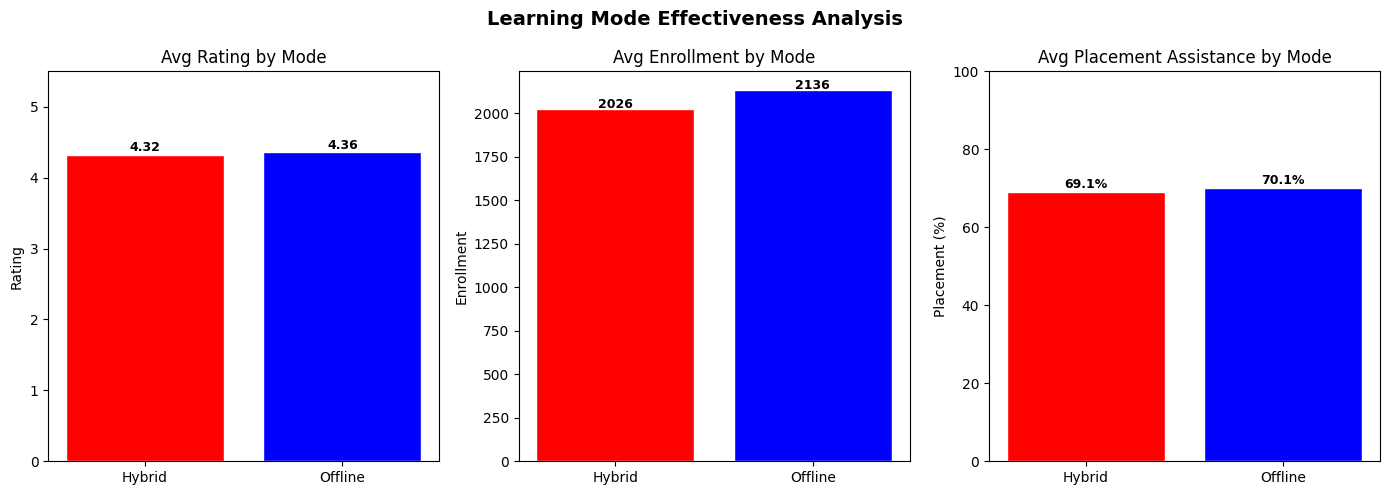

In [42]:
mode_df = df.groupby('mode').agg(
    avg_rating     = ('rating', 'mean'),
    avg_enrollment = ('enrollment', 'mean'),
    avg_placement  = ('placement_assistance', 'mean')
).reset_index()

print(mode_df)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = ['red', 'blue', 'yellow']

axes[0].bar(mode_df['mode'], mode_df['avg_rating'], color=colors, edgecolor='white')
axes[0].set_title("Avg Rating by Mode")
axes[0].set_ylabel("Rating")
axes[0].set_ylim(0, 5.5)
for i, val in enumerate(mode_df['avg_rating']):
    axes[0].text(i, val + 0.05, f"{val:.2f}", ha='center', fontsize=9, fontweight='bold')


axes[1].bar(mode_df['mode'], mode_df['avg_enrollment'], color=colors, edgecolor='white')
axes[1].set_title("Avg Enrollment by Mode")
axes[1].set_ylabel("Enrollment")
for i, val in enumerate(mode_df['avg_enrollment']):
    axes[1].text(i, val + 5, f"{val:.0f}", ha='center', fontsize=9, fontweight='bold')

axes[2].bar(mode_df['mode'], mode_df['avg_placement'], color=colors, edgecolor='white')
axes[2].set_title("Avg Placement Assistance by Mode")
axes[2].set_ylabel("Placement (%)")
axes[2].set_ylim(0, 100)
for i, val in enumerate(mode_df['avg_placement']):
    axes[2].text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold')

plt.suptitle("Learning Mode Effectiveness Analysis", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
4.Credibility Score for Training Institutes Goal Measure the credibility and reliability of training institutes. 

                        company  credibility_score
7                          NIIT           2.265631
4      Great Learning Institute           2.245878
0                  AnalytixLabs           2.240783
3                     DataMites           2.235726
6  Intellipaat Bangalore Center           2.232807
5            Imarticus Learning           2.228442
1           Basant Technologies           2.228031
2           Besant Technologies           2.212008


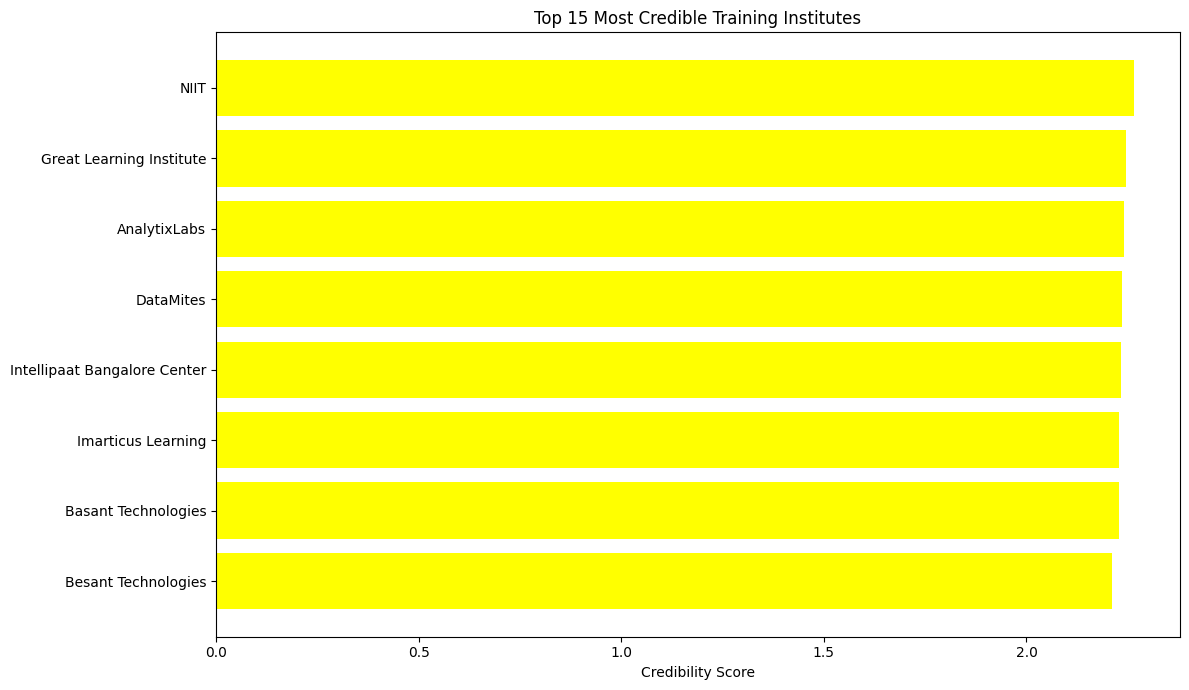

In [47]:
df['language_score'] = df['languages'].apply(lambda x: min(len(str(x).split(',')), 3) / 3)

df['credibility_score'] = (
    (0.4 * df['rating']) +
    (0.3 * df['certification']) +
    (0.2 * df['placement_assistance'] / 100) +
    (0.1 * df['language_score'])
)

company_scores = df.groupby('company')['credibility_score'].mean().reset_index()
company_scores = company_scores.sort_values('credibility_score', ascending=False).head(15)
print(company_scores)
plt.figure(figsize=(12, 7))
plt.barh(company_scores['company'], company_scores['credibility_score'], color='yellow')
plt.xlabel("Credibility Score")
plt.title("Top 15 Most Credible Training Institutes")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
5. Enrollment Trend Analysis
Goal
Help EdTech companies understand which courses attract the most students.

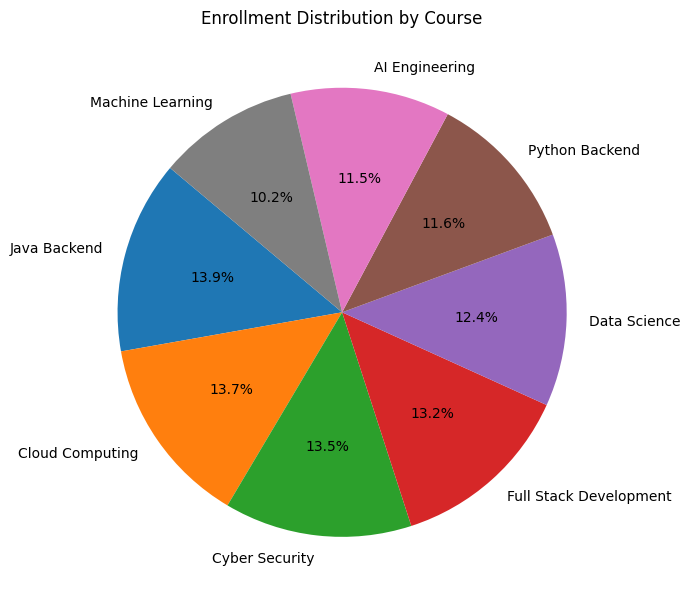

In [50]:
course_enrollment = df.groupby('course')['enrollment'].sum().reset_index() 
course_enrollment = course_enrollment.sort_values('enrollment', ascending=False)

plt.figure(figsize=(7,7))

plt.pie(
    course_enrollment['enrollment'],
    labels=course_enrollment['course'],
    autopct='%1.1f%%',
    startangle=140
)

plt.title("Enrollment Distribution by Course")

plt.tight_layout()
plt.show()

In [ ]:
6. Pricing Optimization Analysis
Goal
Help companies determine whether course pricing is optimal.

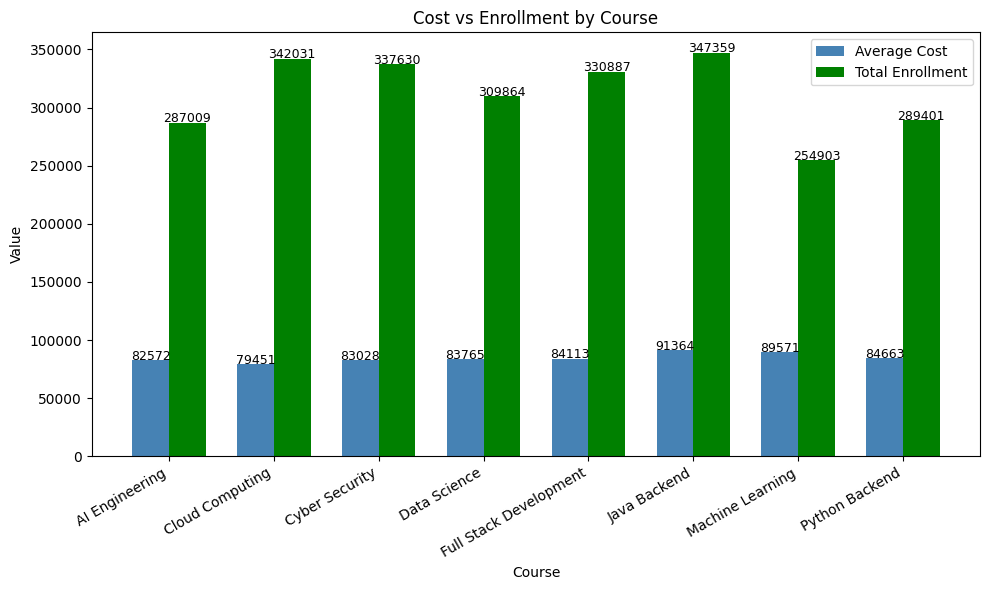

In [54]:

x = np.arange(len(course_df))
width = 0.35

plt.figure(figsize=(10,6))

bars1 = plt.bar(x - width/2, course_df['cost'], width,
                label='Average Cost', color='steelblue')

bars2 = plt.bar(x + width/2, course_df['enrollment'], width,
                label='Total Enrollment', color='green')

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{height:.0f}', ha='center', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 200,
             f'{height:.0f}', ha='center', fontsize=9)

plt.xlabel("Course")
plt.ylabel("Value")
plt.title("Cost vs Enrollment by Course")

plt.xticks(x, course_df['course'], rotation=30, ha='right')

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
7. Scholarship Impact Analysis
Goal
Analyze how scholarships influence student enrollment.

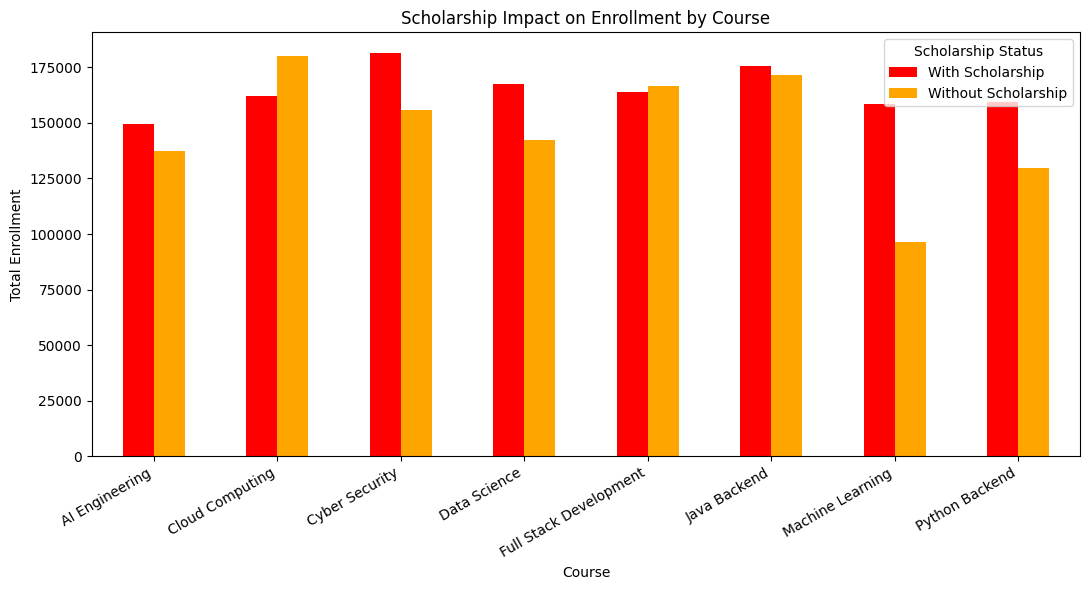

In [58]:

df['scholarship_status'] = df['scholarships'].apply(lambda x: 'With Scholarship' if x == 1 else 'Without Scholarship')

grouped = df.groupby(['course', 'scholarship_status'])['enrollment'].sum().reset_index()
pivot = grouped.pivot(index='course', columns='scholarship_status', values='enrollment').fillna(0)

pivot.plot(kind='bar', figsize=(11, 6), color=['red', 'orange'])

plt.xlabel("Course")
plt.ylabel("Total Enrollment")
plt.title("Scholarship Impact on Enrollment by Course")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Scholarship Status")
plt.tight_layout()
plt.show()

In [ ]:
8.Placement Assistance Performance Analysis
Goal
Evaluate how placement assistance affects course popularity.

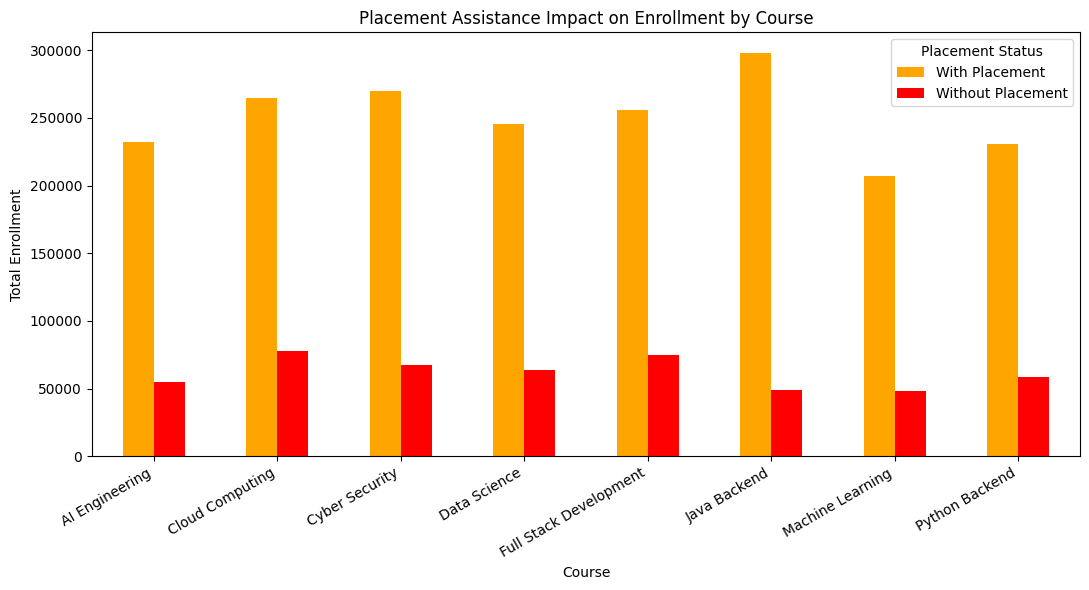

In [62]:
df['placement_status'] = df['placement_assistance'].apply(lambda x: 'With Placement' if x > 0 else 'Without Placement')

grouped = df.groupby(['course', 'placement_status'])['enrollment'].sum().reset_index()

pivot = grouped.pivot(index='course', columns='placement_status', values='enrollment').fillna(0)

pivot.plot(kind='bar', figsize=(11, 6), color=['orange', 'red'])

plt.xlabel("Course")
plt.ylabel("Total Enrollment")
plt.title("Placement Assistance Impact on Enrollment by Course")
plt.xticks(rotation=30, ha='right')
plt.legend(title="Placement Status")
plt.tight_layout()
plt.show()

In [ ]:
9. Course Success Prediction Model
Goal
Predict the probability of a course becoming successful based on multiple factors such as
rating, cost, placement assistance, and learning mode.

C:\Users\Administrator\AppData\Local\Temp\ipykernel_6916\2706451264.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(course_df['course'], rotation=30,)


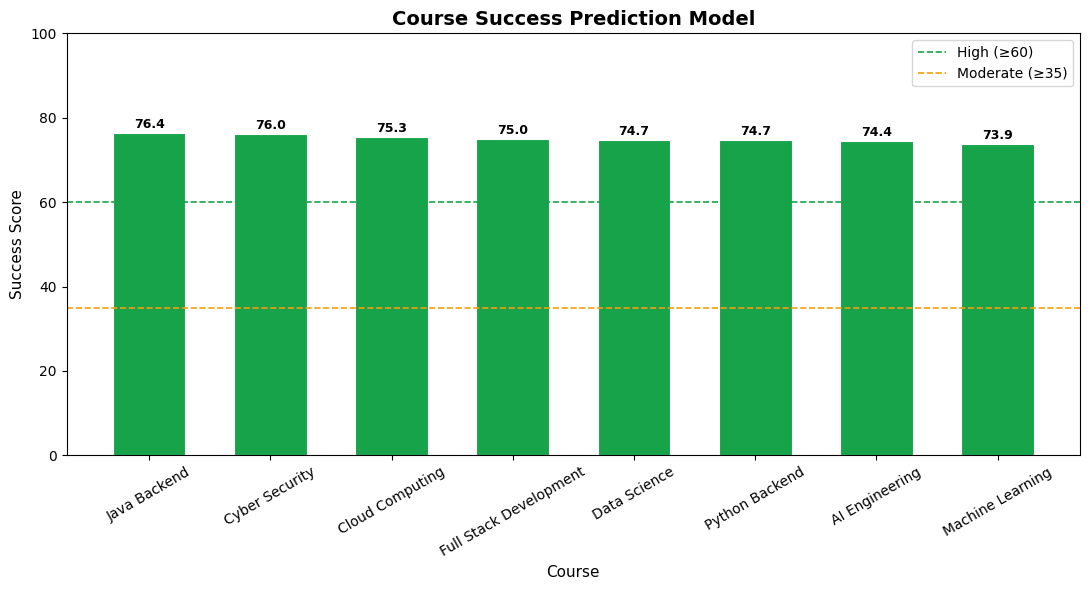

In [66]:

df['success_score'] = (
    0.40 * df['rating_score'] +
    0.25 * df['enroll_score'] +
    0.20 * df['placement_score'] +
    0.10 * df['cert_score'] +
    0.05 * df['mode_score']
) * 100

def classify(s):
    if s >= 60:   return 'High Success'
    elif s >= 35: return 'Moderate Success'
    else:         return 'Low Success'

df['category'] = df['success_score'].apply(classify)

course_df = df.groupby('course')['success_score'].mean().reset_index()
course_df = course_df.sort_values('success_score', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(course_df['course'], course_df['success_score'],
              color=colors, edgecolor='white', linewidth=0.8, width=0.6)

for bar, val in zip(bars, course_df['success_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}", ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.axhline(60, color='#16a34a', linestyle='--', linewidth=1.2, label='High (≥60)')
ax.axhline(35, color='#f59e0b', linestyle='--', linewidth=1.2, label='Moderate (≥35)')

ax.set_xlabel("Course", fontsize=11)
ax.set_ylabel("Success Score", fontsize=11)
ax.set_title("Course Success Prediction Model", fontsize=14, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_xticklabels(course_df['course'], rotation=30,)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
10. Smart Institute Ranking System
Goal
Create a data-driven ranking system for EdTech institutes based on multiple quality indicators.


===== Smart Institute Ranking =====
 rank                      company     score category
    1                         NIIT 74.637543  Premium
    2                    DataMites 74.013282  Premium
    3     Great Learning Institute 73.567619  Premium
    4                 AnalytixLabs 73.239925  Premium
    5           Imarticus Learning 73.132219  Premium
    6          Basant Technologies 72.799296  Premium
    7 Intellipaat Bangalore Center 72.328211  Premium
    8          Besant Technologies 71.791775  Premium


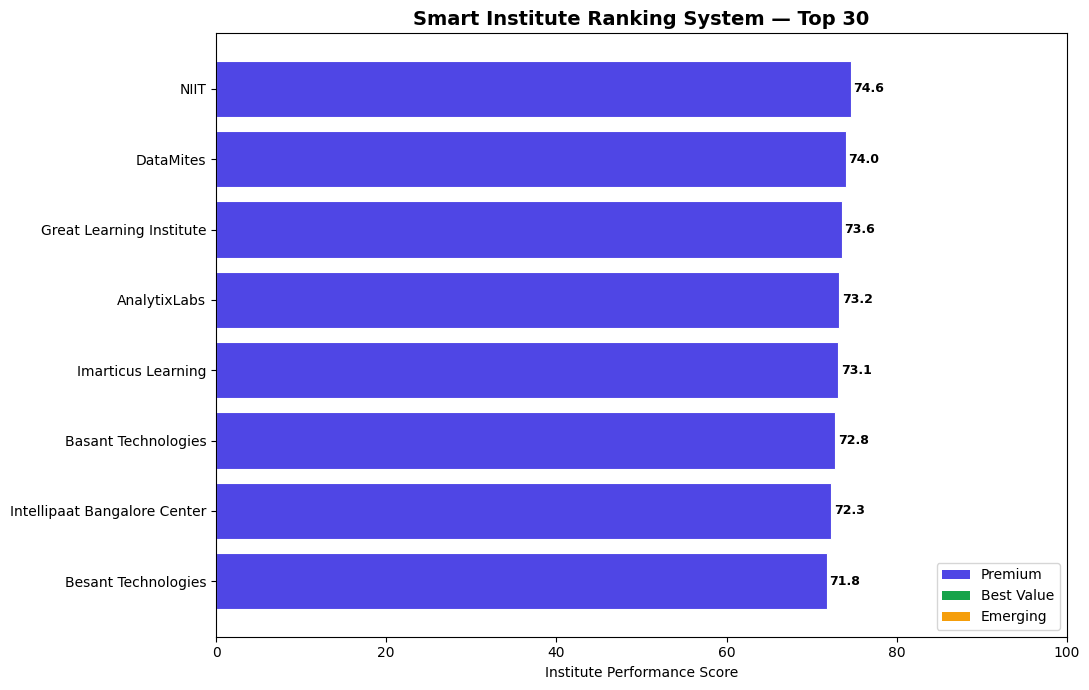

In [68]:
df['rating_norm']      = df['rating'] / df['rating'].max()
df['placement_norm']   = df['placement_assistance'] / 100
df['enroll_norm']      = df['enrollment'] / df['enrollment'].max()
df['cert_norm']        = df['certification']
df['afford_norm']      = 1 - (df['cost'] / df['cost'].max())  # lower cost = better

df['institute_score'] = (
    0.35 * df['rating_norm']    +
    0.25 * df['placement_norm'] +
    0.20 * df['enroll_norm']    +
    0.10 * df['cert_norm']      +
    0.10 * df['afford_norm']
) * 100

# Group by institute
inst_df = df.groupby('company').agg(
    score      = ('institute_score', 'mean'),
    avg_cost   = ('cost', 'mean'),
    avg_rating = ('rating', 'mean')
).reset_index()

inst_df = inst_df.sort_values('score', ascending=False).reset_index(drop=True)
inst_df['rank'] = inst_df.index + 1

# Classify institutes
def classify(row):
    if row['score'] >= 65:                              return 'Premium'
    elif row['avg_cost'] < df['cost'].mean() * 0.85:   return 'Best Value'
    else:                                               return 'Emerging'

inst_df['category'] = inst_df.apply(classify, axis=1)

# Print ranked table
print("\n===== Smart Institute Ranking =====")
print(inst_df[['rank','company','score','category']].to_string(index=False))

# Color map
color_map = {'Premium': '#4f46e5', 'Best Value': '#16a34a', 'Emerging': '#f59e0b'}
colors = inst_df['category'].map(color_map)

# Plot - Top 15
top15 = inst_df.head(30)
colors15 = top15['category'].map(color_map)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(top15['company'][::-1], top15['score'][::-1],
               color=colors15[::-1], edgecolor='white', linewidth=0.8)

# Value labels
for bar, val in zip(bars, top15['score'][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4f46e5', label='Premium'),
                   Patch(facecolor='#16a34a', label='Best Value'),
                   Patch(facecolor='#f59e0b', label='Emerging')]
ax.legend(handles=legend_elements, loc='lower right')

ax.set_xlabel("Institute Performance Score")
ax.set_title("Smart Institute Ranking System — Top 30", fontsize=14, fontweight='bold')
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()